# 🐭 CheeseWorld — Q-Learning desde cero

En este notebook implementaremos **Q-Learning paso a paso**, separando claramente:

- **Environment (`CheeseWorld`)**: define el mundo, las acciones válidas, las transiciones y las recompensas.
- **Agent (`QLearningAgent`)**: mantiene la Q-table, selecciona acciones con $\epsilon$-greedy y actualiza $Q(s,a)$.
- **Training loop**: conecta al agente con el ambiente durante múltiples episodios.

La actualización que implementaremos es:

$$
Q(s,a)\leftarrow Q(s,a)+
\alpha\left[
r+\gamma\max_{a'}Q(s',a')-Q(s,a)
\right]
$$

## 1. El mundo

Usaremos un grid de **2 × 3** estados:

| | Columna 0 | Columna 1 | Columna 2 |
|---|---:|---:|---:|
| **Fila 0** | $S_0$ 🐭 | $S_1$ 🧀 `+1` | $S_2$ |
| **Fila 1** | $S_3$ | $S_4$ ☠️ `-10` | $S_5$ 🧀🧀 `+10` |

El ratón inicia en $S_0=(0,0)$.

Los estados $S_4$ y $S_5$ son **terminales**: al llegar a cualquiera de ellos termina el episodio.

> La recompensa se recibe **al entrar al nuevo estado**.

## 2. Imports

In [ ]:
import random
import pandas as pd

## 3. Environment: `CheeseWorld`

El ambiente responde a la interacción:

$$
(s,a)\longrightarrow(s',r,\text{done})
$$

El ambiente **no aprende** y **no decide qué acción tomar**. Solo define qué ocurre cuando el agente ejecuta una acción.

In [ ]:
class CheeseWorld:
    def __init__(self):
        self.rows = 2
        self.cols = 3

        # Estados representados como coordenadas (fila, columna)
        self.states = [
            (0, 0), (0, 1), (0, 2),
            (1, 0), (1, 1), (1, 2)
        ]

        self.start_state = (0, 0)

        # Recompensa recibida al entrar a cada estado
        self.rewards = {
            (0, 0): 0,
            (0, 1): 1,     # queso pequeño
            (0, 2): 0,
            (1, 0): 0,
            (1, 1): -10,   # veneno
            (1, 2): 10     # queso grande
        }

        self.terminal_states = {
            (1, 1),
            (1, 2)
        }

        self.actions = ["up", "down", "left", "right"]
        self.state = self.start_state

    def possible_actions(self, state):
        """Retorna las acciones válidas desde un estado."""

        if state in self.terminal_states:
            return []

        row, col = state
        actions = []

        if row > 0:
            actions.append("up")

        if row < self.rows - 1:
            actions.append("down")

        if col > 0:
            actions.append("left")

        if col < self.cols - 1:
            actions.append("right")

        return actions

    def step(self, action):
        """Ejecuta una acción y retorna (next_state, reward, done)."""

        if action not in self.possible_actions(self.state):
            raise ValueError(
                f"Invalid action {action!r} from state {self.state}"
            )

        row, col = self.state

        if action == "up":
            next_state = (row - 1, col)
        elif action == "down":
            next_state = (row + 1, col)
        elif action == "left":
            next_state = (row, col - 1)
        elif action == "right":
            next_state = (row, col + 1)

        reward = self.rewards[next_state]
        done = next_state in self.terminal_states

        self.state = next_state

        return next_state, reward, done

    def reset(self):
        """Reinicia el episodio en el estado inicial."""
        self.state = self.start_state
        return self.state

### Prueba rápida del ambiente

In [ ]:
env = CheeseWorld()

state = env.reset()

print("Estado inicial:", state)
print("Acciones posibles:", env.possible_actions(state))

next_state, reward, done = env.step("right")

print("\nDespués de mover right:")
print("Next state:", next_state)
print("Reward:", reward)
print("Done:", done)

Estado inicial: (0, 0)
Acciones posibles: ['down', 'right']

Después de mover right:
Next state: (0, 1)
Reward: 1
Done: False


## 4. Agente Q-Learning

El agente mantiene una estimación:

$$
Q(s,a)
$$

para cada par **estado–acción válido**.

Inicialmente:

$$
Q(s,a)=0 \qquad \forall(s,a)
$$

La acción se selecciona con una política **$\epsilon$-greedy**:

$$
a=
\begin{cases}
\text{acción aleatoria} & \text{con probabilidad }\epsilon\\
\arg\max_a Q(s,a) & \text{con probabilidad }1-\epsilon
\end{cases}
$$

In [ ]:
class QLearningAgent:
    def __init__(self, env, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

        # Q(s,a) = 0 para cada par estado-acción válido
        self.Q = {
            state: {
                action: 0.0
                for action in env.possible_actions(state)
            }
            for state in env.states
        }

    def choose_action(self, state):
        """Selecciona una acción usando epsilon-greedy."""

        actions = self.env.possible_actions(state)

        # Exploration
        if random.random() < self.epsilon:
            return random.choice(actions)

        # Exploitation
        max_q = max(self.Q[state].values())

        # Puede haber varias acciones empatadas con el mismo Q máximo
        best_actions = [
            action
            for action, q_value in self.Q[state].items()
            if q_value == max_q
        ]

        return random.choice(best_actions)

    def update_q(self, state, action, reward, next_state, done):
        """Aplica una actualización de Q-Learning."""

        current_q = self.Q[state][action]

        # En un estado terminal no existe valor futuro
        if done:
            best_next_q = 0.0
        else:
            best_next_q = max(self.Q[next_state].values())

        # TD target: r + gamma max_a' Q(s', a')
        td_target = reward + self.gamma * best_next_q

        # TD error
        td_error = td_target - current_q

        # Q(s,a) <- Q(s,a) + alpha * TD error
        self.Q[state][action] = (
            current_q + self.alpha * td_error
        )

### Visualizar la Q-table

In [ ]:
def q_table(agent):
    """Retorna la Q-table como DataFrame para visualizarla mejor."""

    rows = []

    for state in agent.env.states:
        row = {"state": state}

        for action in agent.env.actions:
            row[action] = agent.Q[state].get(action, None)

        rows.append(row)

    return pd.DataFrame(rows).set_index("state")


env = CheeseWorld()
agent = QLearningAgent(env)

q_table(agent)

,up,down,left,right
state,,,,
"(0, 0)",NaN,0.0,NaN,0.0
"(0, 1)",NaN,0.0,0.0,0.0
"(0, 2)",NaN,0.0,0.0,NaN
"(1, 0)",0.0,NaN,NaN,0.0
"(1, 1)",NaN,NaN,NaN,NaN
"(1, 2)",NaN,NaN,NaN,NaN


## 5. Una actualización controlada

Antes de entrenar, hagamos **una sola transición** manualmente.

Forzamos:

$$
S_0 \xrightarrow{\text{right},\,+1} S_1
$$

Como inicialmente todos los valores $Q(S_1,a')$ son cero:

$$
\max_{a'}Q(S_1,a')=0
$$

Con $\alpha=0.1$ y $\gamma=0.9$:

$$
Q(S_0,\text{right})
=
0+
0.1\left[
1+0.9(0)-0
\right]
=
0.1
$$

In [ ]:
env = CheeseWorld()
agent = QLearningAgent(
    env,
    alpha=0.1,
    gamma=0.9,
    epsilon=0.1
)

state = env.reset()
action = "right"

next_state, reward, done = env.step(action)

print("Transition:")
print(f"{state} --{action} / r={reward}--> {next_state}")

print("\nQ before update:")
print(agent.Q[state])

agent.update_q(
    state,
    action,
    reward,
    next_state,
    done
)

print("\nQ after update:")
print(agent.Q[state])

Transition:
(0, 0) --right / r=1--> (0, 1)

Q before update:
{'down': 0.0, 'right': 0.0}

Q after update:
{'down': 0.0, 'right': 0.1}


## 6. Un episodio completo

En cada paso repetimos:

1. Observar el estado actual $s$.
2. Elegir una acción $a$ con $\epsilon$-greedy.
3. Ejecutar $a$ en el ambiente.
4. Observar $r$, $s'$ y si el episodio terminó.
5. Actualizar $Q(s,a)$.
6. Continuar desde $s'$.

In [ ]:
def run_one_episode(env, agent, verbose=True):
    state = env.reset()
    done = False
    total_reward = 0
    step_number = 0

    while not done:
        step_number += 1

        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)

        q_before = agent.Q[state][action]

        agent.update_q(
            state,
            action,
            reward,
            next_state,
            done
        )

        q_after = agent.Q[state][action]
        total_reward += reward

        if verbose:
            print(f"Step {step_number}")
            print(f"  State      : {state}")
            print(f"  Action     : {action}")
            print(f"  Reward     : {reward}")
            print(f"  Next state : {next_state}")
            print(f"  Q before   : {q_before:.4f}")
            print(f"  Q after    : {q_after:.4f}")
            print()

        state = next_state

    return total_reward

In [ ]:
# Un episodio desde Q = 0
env = CheeseWorld()
agent = QLearningAgent(env)

total_reward = run_one_episode(env, agent)

print("Total reward:", total_reward)

Step 1
  State      : (0, 0)
  Action     : right
  Reward     : 1
  Next state : (0, 1)
  Q before   : 0.0000
  Q after    : 0.1000

Step 2
  State      : (0, 1)
  Action     : down
  Reward     : -10
  Next state : (1, 1)
  Q before   : 0.0000
  Q after    : -1.0000

Total reward: -9


## 7. Entrenamiento

Ahora repetimos el episodio muchas veces. La Q-table se va ajustando a partir de las experiencias del agente.

In [ ]:
def train(env, agent, episodes=1000):
    rewards = []

    for _ in range(episodes):
        total_reward = run_one_episode(
            env,
            agent,
            verbose=False
        )
        rewards.append(total_reward)

    return rewards

## 8. Ver cómo aprende el ratón

Comparemos el mismo agente en tres momentos:

1. **Sin entrenamiento:** random walk.
2. **Después de 20 episodios:** política parcialmente aprendida.
3. **Después de 1000 episodios:** política entrenada.


In [ ]:
def trajectory(env, agent=None, random_policy=False, max_steps=20):
    state = env.reset()
    path = [state]
    total_reward = 0

    for _ in range(max_steps):
        if state in env.terminal_states:
            break

        if random_policy:
            action = random.choice(env.possible_actions(state))
        else:
            q_values = agent.Q[state]
            max_q = max(q_values.values())
            best_actions = [
                a for a, q in q_values.items()
                if q == max_q
            ]
            action = random.choice(best_actions)

        next_state, reward, done = env.step(action)
        path.append(next_state)
        total_reward += reward
        state = next_state

        if done:
            break

    return path, total_reward


In [ ]:
random.seed(7)

# 1. Sin entrenamiento
env_random = CheeseWorld()
path_random, reward_random = trajectory(
    env_random,
    random_policy=True
)

# 2. Pocos episodios
env_early = CheeseWorld()
agent_early = QLearningAgent(env_early, alpha=0.1, gamma=0.9, epsilon=0.1)
train(env_early, agent_early, episodes=20)
path_early, reward_early = trajectory(env_early, agent_early)

# 3. Entrenado
env_trained = CheeseWorld()
agent_trained = QLearningAgent(env_trained, alpha=0.1, gamma=0.9, epsilon=0.1)
train(env_trained, agent_trained, episodes=1000)
path_trained, reward_trained = trajectory(env_trained, agent_trained)

print("Random walk:", path_random, "reward =", reward_random)
print("20 episodios:", path_early, "reward =", reward_early)
print("1000 episodios:", path_trained, "reward =", reward_trained)


Random walk: [(0, 0), (0, 1), (1, 1)] reward = -9
20 episodios: [(0, 0), (0, 1), (0, 2), (1, 2)] reward = 11
1000 episodios: [(0, 0), (0, 1), (0, 2), (1, 2)] reward = 11


/tmp/ipykernel_913/3080606551.py:54: UserWarning: Glyph 129472 (\N{CHEESE WEDGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129472 (\N{CHEESE WEDGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


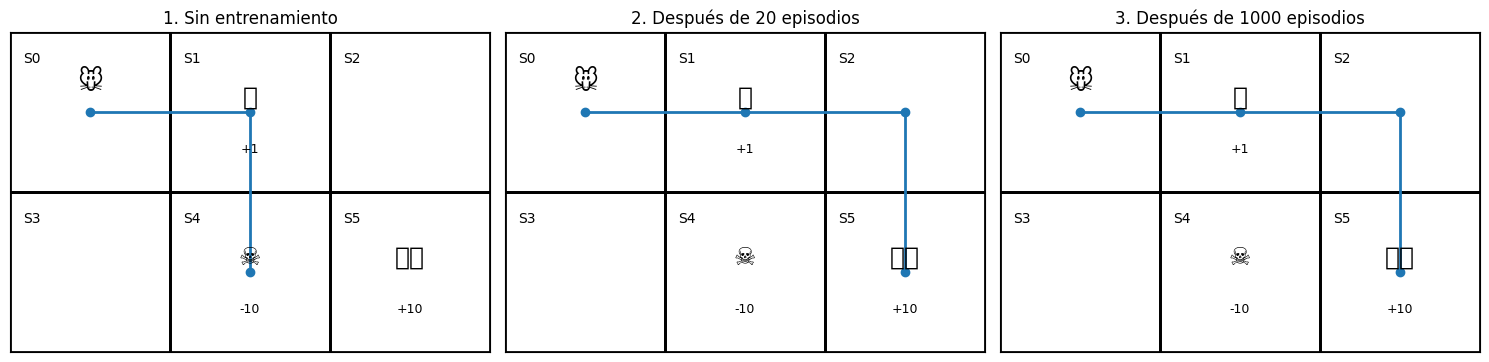

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def plot_comparison(env, paths, titles):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, path, title in zip(axes, paths, titles):

        for row in range(env.rows):
            for col in range(env.cols):
                x = col
                y = env.rows - 1 - row

                ax.add_patch(
                    Rectangle((x, y), 1, 1, fill=False, linewidth=2)
                )

                state_number = row * env.cols + col
                ax.text(
                    x + 0.08,
                    y + 0.88,
                    f"S{state_number}",
                    fontsize=10,
                    va="top"
                )

        special = {
            (0, 1): ("🧀", "+1"),
            (1, 1): ("☠", "-10"),
            (1, 2): ("🧀🧀", "+10"),
        }

        for state, (symbol, reward) in special.items():
            row, col = state
            x = col + 0.5
            y = env.rows - 1 - row + 0.55
            ax.text(x, y, symbol, ha="center", fontsize=18)
            ax.text(x, y - 0.3, reward, ha="center", fontsize=9)

        xs = [col + 0.5 for row, col in path]
        ys = [env.rows - 1 - row + 0.5 for row, col in path]

        ax.plot(xs, ys, marker="o", linewidth=2)
        ax.text(xs[0], ys[0] + 0.15, "🐭", ha="center", fontsize=18)

        ax.set_xlim(0, env.cols)
        ax.set_ylim(0, env.rows)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title)

    plt.tight_layout()
    plt.show()


plot_comparison(
    CheeseWorld(),
    [path_random, path_early, path_trained],
    [
        "1. Sin entrenamiento",
        "2. Después de 20 episodios",
        "3. Después de 1000 episodios"
    ]
)


### ¿Qué cambió?

El ambiente no cambió. Lo que cambió fueron los valores

$$
Q(s,a)
$$

aprendidos por el agente.

Al final, la política greedy selecciona:

$$
\pi(s)=\arg\max_a Q(s,a)
$$


In [ ]:
print("Q-table final:")
display(q_table(agent_trained))


Q-table final:


,up,down,left,right
state,,,,
"(0, 0)",NaN,7.120958,NaN,9.100
"(0, 1)",NaN,-9.942736,7.764677,9.000
"(0, 2)",NaN,10.000000,9.058221,NaN
"(1, 0)",8.140479,NaN,NaN,-3.439
"(1, 1)",NaN,NaN,NaN,NaN
"(1, 2)",NaN,NaN,NaN,NaN


## 9. Política final


In [ ]:
def greedy_policy(agent):
    policy = {}

    for state in agent.Q:
        if state in agent.env.terminal_states:
            policy[state] = "terminal"
            continue

        q_values = agent.Q[state]
        policy[state] = max(q_values, key=q_values.get)

    return policy


greedy_policy(agent_trained)


{(0, 0): 'right',
 (0, 1): 'right',
 (0, 2): 'down',
 (1, 0): 'up',
 (1, 1): 'terminal',
 (1, 2): 'terminal'}

La comparación anterior permite ver el aprendizaje desde el comportamiento.  
La Q-table y la política final muestran **qué aprendió internamente el agente**.
